# State-Transition Cost-Utility Analysis

This notebook is the reproducible analysis record for the individual-level state-transition
microsimulation. The cohort enters at age 1 and exits immediately before age 12 (11 years; 572
weekly cycles). All model calculations use Iranian rial (IRR).

The notebook separates deterministic base-case results, structural scenarios, internal
validation/calibration, probabilistic analysis, one-way sensitivity analysis, and auditable
sample outputs. Production runs use checkpointed Parquet files and can be resumed safely.

In [1]:
from __future__ import annotations
%pip install -e ..
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "modular_models").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from modular_models.state_transition.reporting import (
    auditable_cycle_sample,
    auditable_patient_sample,
    break_even_factor_price,
    calibration_table,
    ceac_table,
    cost_effectiveness_quadrants,
    economic_summary_table,
    evpi_max,
    evpi_table,
    exact_ceac_table,
    extended_validation_table,
    factor_price_policy_table,
    factor_price_probability_thresholds,
    factor_price_psa_table,
    incremental_outcomes,
    monte_carlo_convergence_table,
    owsa_parameter_ranking,
    parameter_table,
    psa_iteration_convergence,
    psa_precision_summary,
    psa_summary,
    runtime_audit_table,
    selected_ceac_table,
    strategy_outcomes,
    validation_table,
    wtp_sensitivity_table,
    wtp_threshold_summary,
)
from modular_models.state_transition.report_plots import (
    plot_calibration,
    plot_ceac_frame,
    plot_clinical_outcomes,
    plot_evpi,
    plot_factor_price_policy,
    plot_inmb_threshold,
    plot_inner_loop_precision,
    plot_monte_carlo_convergence,
    plot_mortality,
    plot_owsa_frame,
    plot_psa_convergence,
    plot_psa_plane,
    plot_scenario_nmb_bars,
)

Obtaining file:///c:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for hemophilia-state-transition-model (pyproject.toml): started
  Building editable for hemophilia-state-transition-model (pyproject.toml): finished with status 'done'
  Created wheel for hemophilia-state-transition-model: filename=hemophilia_state_transition_model-1.0.0-0.editable-py3-none-any.whl size=10137 sha256=a52ee6850cd668b5c4091fff9bed97f0fd50

## 1. Locked analysis configuration

Long run (Production) switches are intentionally explicit.
Set a switch to `True` only after reviewing the configuration and available compute.
Completed PSA and OWSA batches resume from their existing checkpoints.

In [2]:
PRODUCTION_PATIENTS = 50_000
PSA_PATIENTS_PER_ITERATION = 5_000
PSA_ITERATIONS = 2_500
PSA_BACKEND = "cpu"
MASTER_SEED = 20_260_813
WTP_IRR_PER_QALY = 18_000_000_000

RUN_BASE_CASE = True
RUN_STRUCTURAL_SCENARIOS = False
RUN_PRODUCTION_PSA = False
RUN_PRODUCTION_OWSA = False

# Twelve worker processes use every logical CPU core on the production machine.
# CPU-JIT was faster on the installed GTX 1660 Ti for this FP64 workload.
PSA_JOBS = 12
PSA_BATCH_SIZE = 24
OWSA_JOBS = 0

import polars as pl

configuration = pl.DataFrame(
    [
        {
            "setting": "deterministic_patients_per_strategy",
            "value": PRODUCTION_PATIENTS,
        },
        {
            "setting": "psa_patients_per_iteration_per_strategy",
            "value": PSA_PATIENTS_PER_ITERATION,
        },
        {"setting": "psa_iterations_runtime_selected", "value": PSA_ITERATIONS},
        {"setting": "psa_compute_backend", "value": PSA_BACKEND},
        {"setting": "psa_worker_processes", "value": PSA_JOBS},
        {"setting": "master_seed", "value": MASTER_SEED},
        {"setting": "wtp_irr_per_qaly", "value": WTP_IRR_PER_QALY},
        {"setting": "entry_age", "value": 1},
        {"setting": "exit_age_exclusive", "value": 12},
        {"setting": "weekly_cycles", "value": 11 * 52},
    ]
)
configuration

setting,value
str,str
"""deterministic_patients_per_str…","""50000"""
"""psa_patients_per_iteration_per…","""5000"""
"""psa_iterations_runtime_selecte…","""2500"""
"""psa_compute_backend""","""cpu"""
"""psa_worker_processes""","""12"""
"""master_seed""","""20260813"""
"""wtp_irr_per_qaly""","""18000000000"""
"""entry_age""","""1"""
"""exit_age_exclusive""","""12"""


## 2. Input audit and provenance

Inputs are loaded through the typed context. The table includes base values, deterministic
ranges, probabilistic distributions, units, references and explicit assumptions.

In [3]:
from modular_models.state_transition.analysis import StudyRunner
from modular_models.state_transition.context import StudyContext

TABLES = ROOT / "outputs" / "state_transition" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

context = StudyContext.load(ROOT / "app" / "data" / "state_transition")
runner = StudyRunner(context)
inputs = parameter_table(context)
inputs.write_parquet(TABLES / "model_inputs.parquet")
inputs.write_csv(TABLES / "model_inputs.csv")

print(
    f"Validated {len(context.parameters)} parameters, "
    f"{len(context.references)} references and {len(context.scenarios)} scenarios."
)
with pl.Config(tbl_rows=65, tbl_hide_column_data_types=True):
    print(
        inputs.select(
            "parameter_id",
            "base_value",
            "unit",
            "owsa_low",
            "owsa_high",
            "psa_distribution",
        )
    )

Validated 65 parameters, 26 references and 6 scenarios.
shape: (65, 6)
┌─────────────────────┬─────────────┬────────────────────┬──────────┬───────────┬──────────────────┐
│ parameter_id        ┆ base_value  ┆ unit               ┆ owsa_low ┆ owsa_high ┆ psa_distribution │
╞═════════════════════╪═════════════╪════════════════════╪══════════╪═══════════╪══════════════════╡
│ entry_age_years     ┆ 1.0         ┆ year               ┆ null     ┆ null      ┆ fixed            │
│ exit_age_years      ┆ 12.0        ┆ year               ┆ null     ┆ null      ┆ fixed            │
│ cycles_per_year     ┆ 52.0        ┆ cycle/year         ┆ null     ┆ null      ┆ fixed            │
│ days_per_cycle      ┆ 7.0         ┆ model-day/cycle    ┆ null     ┆ null      ┆ fixed            │
│ default_patients    ┆ 100000.0    ┆ patient            ┆ 10000.0  ┆ 200000.0  ┆ fixed            │
│ convergence_thresho ┆ 0.01        ┆ proportion         ┆ null     ┆ null      ┆ fixed            │
│ ld                

## 3. Deterministic base case

The paired strategies use identical first-order random stream identifiers. Patient-level arrays
are retained only here to provide an auditable sample; high-iteration analyses retain aggregated
outcomes to control memory use.

#### 3A. Base-case decision summary

In [4]:
import time

from modular_models.state_transition.trace import TraceSession

base_started = time.perf_counter()
base_trace = TraceSession(max_cycles=5)
base = (
    runner.compare(
        n_patients=PRODUCTION_PATIENTS,
        seed=MASTER_SEED,
        retain_patient_level=True,
        trace=base_trace,
    )
    if RUN_BASE_CASE
    else None
)

if base is None:
    raise RuntimeError(
        "RUN_BASE_CASE must be True when regenerating the final notebook"
    )

base_elapsed_seconds = time.perf_counter() - base_started
OUTPUT = ROOT / "outputs" / "state_transition"
TRACE = OUTPUT / "trace"
FIGURES = OUTPUT / "figures"

TRACE.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

base_trace.write_json(TRACE / "base_case_trace.json")
base_trace.render(TRACE / "base_case_trace.png")

strategy_table = strategy_outcomes(base)
incremental_table = incremental_outcomes(base)
strategy_table.write_parquet(TABLES / "base_case_strategy_outcomes.parquet")
strategy_table.write_csv(TABLES / "base_case_strategy_outcomes.csv")
incremental_table.write_parquet(TABLES / "base_case_incremental_outcomes.parquet")
incremental_table.write_csv(TABLES / "base_case_incremental_outcomes.csv")

print(f"Base-case runtime: {base_elapsed_seconds / 60:.2f} minutes")
strategy_table

Base-case runtime: 0.54 minutes


strategy,cost_irr,qaly,life_years,factor_viii_iu,total_bleeds,joint_bleeds,non_major_non_joint_bleeds,non_ich_major_bleeds,ich_events,pettersson_score,alive_at_end,deaths_total,deaths_background,deaths_ich,mortality_probability,post_ich_count,post_ich_probability
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,i64,f64
"""prophylaxis""",4.0674e10,8.062659,10.970847,1.0026e6,33.48242,11.54382,21.77828,0.15642,0.0039,0.37418,49740,260,245,15,0.0052,50,0.001
"""on_demand""",7.2465e9,7.822101,10.883083,178482.168116,150.27072,107.267,42.1116,0.70476,0.18736,7.79114,48947,1053,244,809,0.02106,2142,0.04284


In [5]:
import numpy as np

# 3A. Base-case decision summary

assert base is not None

decision_summary = pl.DataFrame(
    [
        {
            "wtp_irr_per_qaly": WTP_IRR_PER_QALY,
            "incremental_cost_irr": base.incremental_cost_irr,
            "incremental_qaly": base.incremental_qaly,
            "icer_irr_per_qaly": base.icer_irr_per_qaly,
            "incremental_nmb_irr": base.incremental_nmb_irr,
            "cost_effective": base.incremental_nmb_irr > 0,
            "break_even_wtp_irr_per_qaly": (
                base.incremental_cost_irr / base.incremental_qaly
                if base.incremental_qaly > 0
                else np.nan
            ),
        }
    ]
)

decision_summary.write_csv(TABLES / "base_case_decision_summary.csv")
decision_summary

wtp_irr_per_qaly,incremental_cost_irr,incremental_qaly,icer_irr_per_qaly,incremental_nmb_irr,cost_effective,break_even_wtp_irr_per_qaly
i64,f64,f64,f64,f64,bool,f64
18000000000,3.3428e10,0.240558,1.3896e11,-2.9098e10,false,1.3896e11


#### 3B. Incremental clinical interpretation

In [6]:
incremental_table

incremental_cost_irr,incremental_qaly,icer_irr_per_qaly,incremental_nmb_irr,cost_effective,bleeds_avoided,joint_bleeds_avoided,relative_bleed_reduction,incremental_cost_per_bleed_avoided_irr,absolute_mortality_reduction,relative_mortality_reduction,relative_ich_mortality_reduction,deaths_avoided_per_1000,number_needed_to_treat_to_avoid_one_death
f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64
3.3428e10,0.240558,1.3896e11,-2.9098e10,false,116.7883,95.72318,0.777186,2.8623e8,0.01586,0.753086,0.981459,15.86,63.051702


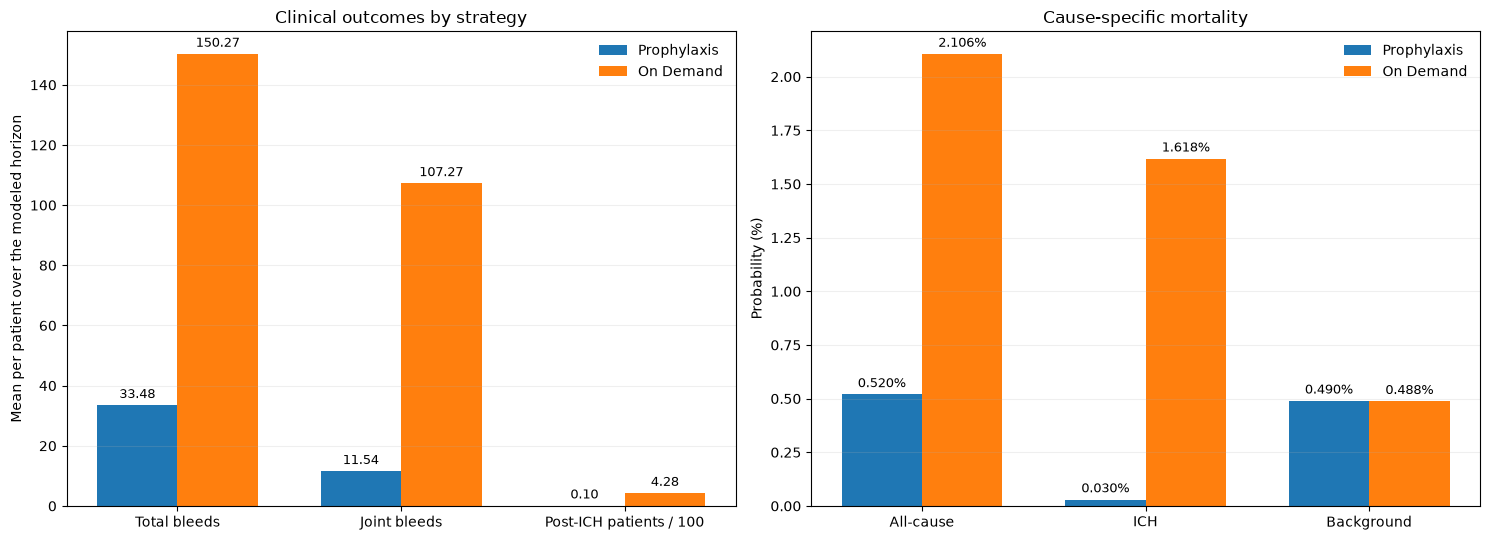

In [7]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_clinical_outcomes(strategy_table, axes[0])
plot_mortality(strategy_table, axes[1])
fig.tight_layout()
fig.savefig(
    FIGURES / "base_case_clinical_and_mortality.png", dpi=300, bbox_inches="tight"
)
fig.savefig(FIGURES / "base_case_clinical_and_mortality.pdf", bbox_inches="tight")
plt.show()

In [8]:
# Deterministic base-case summary

assert base is not None

p = strategy_table.filter(pl.col("strategy") == "prophylaxis").row(0, named=True)
o = strategy_table.filter(pl.col("strategy") == "on_demand").row(0, named=True)


def reduction(reference, intervention):
    if reference == 0:
        return np.nan
    return (reference - intervention) / reference


thesis_base_summary = pl.DataFrame(
    [
        {
            "outcome": "Total bleeds",
            "prophylaxis": p["total_bleeds"],
            "on_demand": o["total_bleeds"],
            "difference_favouring_prophylaxis": (o["total_bleeds"] - p["total_bleeds"]),
            "relative_reduction": reduction(
                o["total_bleeds"],
                p["total_bleeds"],
            ),
            "unit": "events/patient",
        },
        {
            "outcome": "Joint bleeds",
            "prophylaxis": p["joint_bleeds"],
            "on_demand": o["joint_bleeds"],
            "difference_favouring_prophylaxis": (o["joint_bleeds"] - p["joint_bleeds"]),
            "relative_reduction": reduction(
                o["joint_bleeds"],
                p["joint_bleeds"],
            ),
            "unit": "events/patient",
        },
        {
            "outcome": "Non-major non-joint bleeds",
            "prophylaxis": p["non_major_non_joint_bleeds"],
            "on_demand": o["non_major_non_joint_bleeds"],
            "difference_favouring_prophylaxis": (
                o["non_major_non_joint_bleeds"] - p["non_major_non_joint_bleeds"]
            ),
            "relative_reduction": reduction(
                o["non_major_non_joint_bleeds"],
                p["non_major_non_joint_bleeds"],
            ),
            "unit": "events/patient",
        },
        {
            "outcome": "Non-ICH major bleeds",
            "prophylaxis": p["non_ich_major_bleeds"],
            "on_demand": o["non_ich_major_bleeds"],
            "difference_favouring_prophylaxis": (
                o["non_ich_major_bleeds"] - p["non_ich_major_bleeds"]
            ),
            "relative_reduction": reduction(
                o["non_ich_major_bleeds"],
                p["non_ich_major_bleeds"],
            ),
            "unit": "events/patient",
        },
        {
            "outcome": "ICH events",
            "prophylaxis": p["ich_events"],
            "on_demand": o["ich_events"],
            "difference_favouring_prophylaxis": (o["ich_events"] - p["ich_events"]),
            "relative_reduction": reduction(
                o["ich_events"],
                p["ich_events"],
            ),
            "unit": "events/patient",
        },
        {
            "outcome": "Pettersson score",
            "prophylaxis": p["pettersson_score"],
            "on_demand": o["pettersson_score"],
            "difference_favouring_prophylaxis": (
                o["pettersson_score"] - p["pettersson_score"]
            ),
            "relative_reduction": reduction(
                o["pettersson_score"],
                p["pettersson_score"],
            ),
            "unit": "points/patient",
        },
        {
            "outcome": "Post-ICH probability",
            "prophylaxis": p["post_ich_probability"],
            "on_demand": o["post_ich_probability"],
            "difference_favouring_prophylaxis": (
                o["post_ich_probability"] - p["post_ich_probability"]
            ),
            "relative_reduction": reduction(
                o["post_ich_probability"],
                p["post_ich_probability"],
            ),
            "unit": "probability",
        },
        {
            "outcome": "Mortality probability",
            "prophylaxis": p["mortality_probability"],
            "on_demand": o["mortality_probability"],
            "difference_favouring_prophylaxis": (
                o["mortality_probability"] - p["mortality_probability"]
            ),
            "relative_reduction": reduction(
                o["mortality_probability"],
                p["mortality_probability"],
            ),
            "unit": "probability",
        },
        {
            "outcome": "QALY",
            "prophylaxis": p["qaly"],
            "on_demand": o["qaly"],
            "difference_favouring_prophylaxis": (p["qaly"] - o["qaly"]),
            "relative_reduction": None,
            "unit": "QALY/patient",
        },
        {
            "outcome": "Life-years",
            "prophylaxis": p["life_years"],
            "on_demand": o["life_years"],
            "difference_favouring_prophylaxis": (p["life_years"] - o["life_years"]),
            "relative_reduction": None,
            "unit": "LY/patient",
        },
    ]
)

thesis_base_summary.write_csv(TABLES / "thesis_base_case_clinical_summary.csv")

thesis_base_summary

outcome,prophylaxis,on_demand,difference_favouring_prophylaxis,relative_reduction,unit
str,f64,f64,f64,f64,str
"""Total bleeds""",33.48242,150.27072,116.7883,0.777186,"""events/patient"""
"""Joint bleeds""",11.54382,107.267,95.72318,0.892382,"""events/patient"""
"""Non-major non-joint bleeds""",21.77828,42.1116,20.33332,0.482844,"""events/patient"""
"""Non-ICH major bleeds""",0.15642,0.70476,0.54834,0.778052,"""events/patient"""
"""ICH events""",0.0039,0.18736,0.18346,0.979184,"""events/patient"""
"""Pettersson score""",0.37418,7.79114,7.41696,0.951974,"""points/patient"""
"""Post-ICH probability""",0.001,0.04284,0.04184,0.976657,"""probability"""
"""Mortality probability""",0.0052,0.02106,0.01586,0.753086,"""probability"""
"""QALY""",8.062659,7.822101,0.240558,null,"""QALY/patient"""


In [9]:
# Base-case economic summary
assert base is not None
base_economic_summary = economic_summary_table(base)
base_economic_summary.write_csv(TABLES / "thesis_base_case_economic_summary.csv")
base_economic_summary

metric,value,unit
str,f64,str
"""Cost - prophylaxis""",4.0674e10,"""IRR/patient"""
"""Cost - on demand""",7.2465e9,"""IRR/patient"""
"""Incremental cost""",3.3428e10,"""IRR/patient"""
"""Incremental QALY""",0.240558,"""QALY/patient"""
"""ICER""",1.3896e11,"""IRR/QALY"""
"""Incremental NMB""",-2.9098e10,"""IRR/patient"""


In [10]:
# Deterministic WTP threshold analysis and INMB plot

assert base is not None

delta_cost = float(base.incremental_cost_irr)
delta_qaly = float(base.incremental_qaly)
primary_wtp = WTP_IRR_PER_QALY
break_even_wtp = delta_cost / delta_qaly if delta_qaly > 0 else np.nan

selected_wtp = np.array(
    [
        0,
        10_000_000_000,
        18_000_000_000,
        50_000_000_000,
        100_000_000_000,
        125_000_000_000,
        150_000_000_000,
        175_000_000_000,
        200_000_000_000,
        250_000_000_000,
        300_000_000_000,
    ],
    dtype=float,
)

wtp_sensitivity = wtp_sensitivity_table(delta_cost, delta_qaly, selected_wtp)
wtp_sensitivity.write_csv(TABLES / "base_case_wtp_sensitivity.csv")
wtp_sensitivity.write_parquet(TABLES / "base_case_wtp_sensitivity.parquet")

wtp_threshold_summary = wtp_threshold_summary(delta_cost, delta_qaly, primary_wtp)
wtp_threshold_summary.write_csv(TABLES / "base_case_wtp_threshold_summary.csv")

print(f"Primary WTP: {primary_wtp / 1e9:.1f} billion IRR/QALY")
print(f"Break-even WTP: {break_even_wtp / 1e9:.2f} billion IRR/QALY")
wtp_sensitivity

Primary WTP: 18.0 billion IRR/QALY
Break-even WTP: 138.96 billion IRR/QALY


wtp_irr_per_qaly,incremental_nmb_irr,preferred_strategy
f64,f64,str
0.0,-3.3428e10,"""On-demand"""
1.0000e10,-3.1022e10,"""On-demand"""
1.8000e10,-2.9098e10,"""On-demand"""
5.0000e10,-2.1400e10,"""On-demand"""
1.0000e11,-9.3722e9,"""On-demand"""
…,…,…
1.5000e11,2.6557e9,"""Prophylaxis"""
1.7500e11,8.6696e9,"""Prophylaxis"""
2.0000e11,1.4684e10,"""Prophylaxis"""


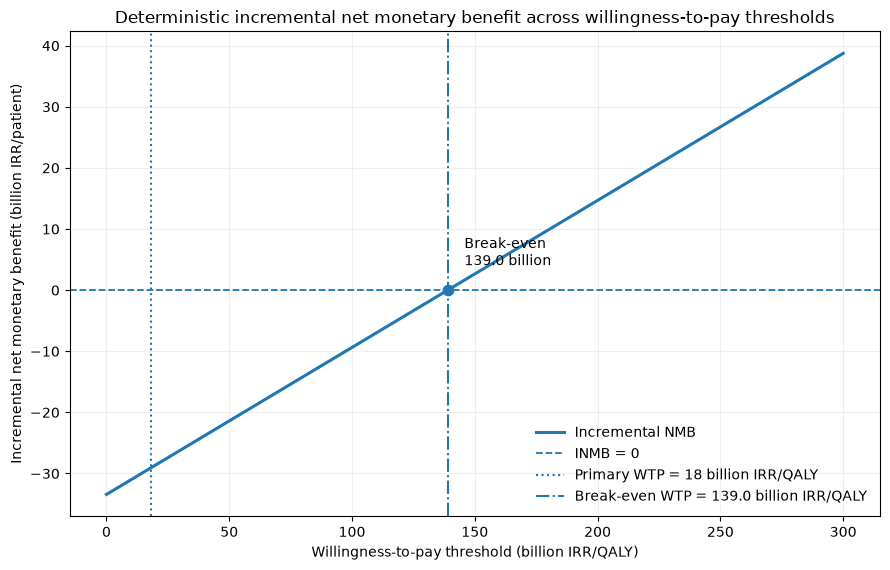

In [11]:
# Deterministic INMB across WTP thresholds

fig, ax = plt.subplots(figsize=(9, 5.8))
plot_inmb_threshold(delta_qaly, delta_cost, primary_wtp, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES / "base_case_wtp_inmb_threshold.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "base_case_wtp_inmb_threshold.pdf", bbox_inches="tight")
plt.show()

####  3C. Deterministic WTP sensitivity

####  3D. Base-case survival curves

## 4. Internal validation and calibration

Verification checks mathematical invariants: population reconciliation, absorbing mortality,
non-negative rewards, exclusive age horizon and cycle count. Internal calibration compares
simulated event rates per observed person-year with the annual rates supplied to the model.
The 5% flag is a diagnostic tolerance, not an external goodness-of-fit claim.

In [12]:
validation = validation_table(context, base)  # type: ignore
calibration = calibration_table(context, base)  # type: ignore
validation.write_csv(TABLES / "model_validation.csv")
calibration.write_csv(TABLES / "internal_calibration.csv")

print(f"Validation checks passed: {validation['passed'].sum()} / {validation.height}")
validation

Validation checks passed: 17 / 17


scope,check,passed,detail
str,str,bool,str
"""prophylaxis""","""population_reconciles""",true,null
"""prophylaxis""","""qaly_non_negative""",true,null
"""prophylaxis""","""qaly_below_undiscounted_horizo…",true,null
"""prophylaxis""","""cost_non_negative""",true,null
"""prophylaxis""","""factor_non_negative""",true,null
…,…,…,…
"""on_demand""","""exit_age_exclusive""",true,null
"""on_demand""","""cycle_count_572""",true,null
"""mortality""","""weekly_probability_background_…",true,"""8.39342631342e-06"""


In [13]:
calibration

strategy,calibration_target,target_rate_per_person_year,simulated_rate_per_person_year,relative_error,absolute_relative_error,within_5_percent,person_year_exposure,expected_events,observed_events,poisson_z_score,within_poisson_95_percent
str,str,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64
"""prophylaxis""","""joint_bleed""",1.05,1.052227,0.002121,0.002121,true,548542.343875,575969.461069,577191.0,1.609562,1.0
"""prophylaxis""","""non_major_non_joint_bleed""",1.985396,1.985105,-0.000147,0.000147,true,548542.343875,1.0891e6,1.088914e6,-0.153102,1.0
"""prophylaxis""","""non_ich_major_bleed""",0.014274,0.014258,-0.001136,0.001136,true,548542.343875,7829.893416,7821.0,-0.100506,1.0
"""prophylaxis""","""intracranial_hemorrhage""",0.00033,0.000355,0.077235,0.077235,false,548542.343875,181.018973,195.0,1.039147,1.0
"""prophylaxis""","""total_bleed""",3.05,3.051945,0.000638,0.000638,true,548542.343875,1.6731e6,1.674121e6,0.8248,1.0
"""on_demand""","""joint_bleed""",9.85,9.856306,0.00064,0.00064,true,544154.157148,5.3599e6,5.36335e6,1.482216,1.0
"""on_demand""","""non_major_non_joint_bleed""",3.868416,3.869455,0.000269,0.000269,true,544154.157148,2.1050e6,2.10558e6,0.389665,1.0
"""on_demand""","""non_ich_major_bleed""",0.064584,0.064757,0.002685,0.002685,true,544154.157148,35143.652085,35238.0,0.503279,1.0
"""on_demand""","""intracranial_hemorrhage""",0.017,0.017216,0.012689,0.012689,true,544154.157148,9250.620672,9368.0,1.220411,1.0


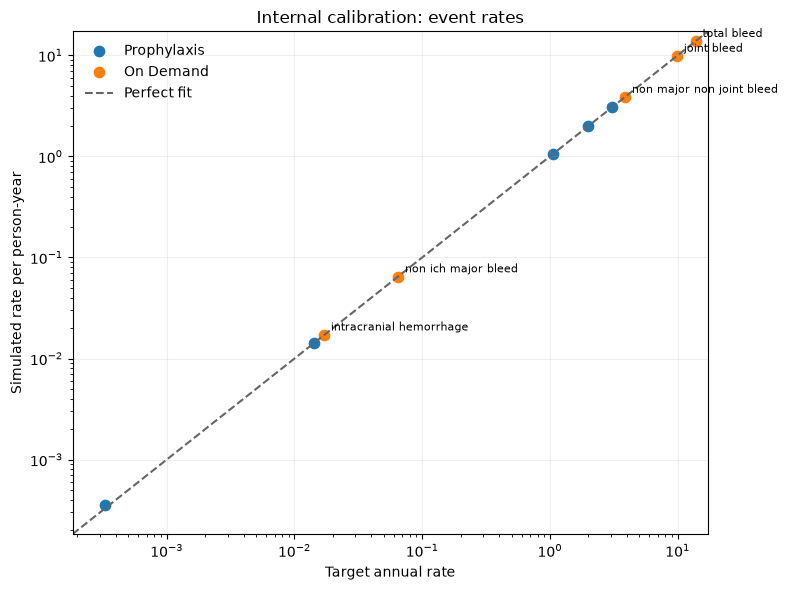

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_calibration(calibration, ax)
fig.tight_layout()
fig.savefig(FIGURES / "internal_calibration.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "internal_calibration.pdf", bbox_inches="tight")
plt.show()

In [15]:
# Extended patient-level invariant audit

assert base is not None
extended_validation = extended_validation_table(base)
extended_validation.write_csv(TABLES / "extended_internal_validation.csv")

print(
    f"Extended validation passed: "
    f"{extended_validation['passed'].sum()} / "
    f"{extended_validation.height}"
)
extended_validation

Extended validation passed: 12 / 12


strategy,check,passed
str,str,bool
"""prophylaxis""","""pettersson_within_0_78""",true
"""prophylaxis""","""patient_qaly_non_negative""",true
"""prophylaxis""","""patient_qaly_not_above_life_ye…",true
"""prophylaxis""","""patient_cost_non_negative""",true
"""prophylaxis""","""patient_factor_non_negative""",true
…,…,…
"""on_demand""","""patient_qaly_non_negative""",true
"""on_demand""","""patient_qaly_not_above_life_ye…",true
"""on_demand""","""patient_cost_non_negative""",true


## 5. Auditable patient and cycle samples

The first table shows individual end-of-horizon outcomes for patients with the greatest bleeding
burden in the retained base-case sample. The trace JSON separately records parameter provenance,
derived weekly Poisson rates and the first five cycle aggregates for both strategies.

In [16]:
assert base is not None
patient_sample = auditable_patient_sample(base, n=10)
patient_sample.write_csv(TABLES / "auditable_patient_sample.csv")
patient_sample

patient_id,life_years,total_qaly,total_cost_irr,total_factor_iu,joint_bleeds,non_major_non_joint_bleeds,non_ich_major_bleeds,ich_events,pettersson_score,ever_post_ich,death_cause,death_age_years,final_state
i64,f64,f64,f64,f64,i32,i32,i32,i32,i16,bool,str,f64,i8
39934,11.0,7.977853,8.9716e9,217067.211538,156,43,0,0,12,false,"""alive""",NaN,0
1221,11.0,7.982433,9.2566e9,231579.423077,151,49,0,0,11,false,"""alive""",NaN,0
2651,11.0,7.986235,8.7075e9,217748.269231,151,36,0,0,11,false,"""alive""",NaN,0
8899,11.0,7.976927,9.5374e9,235872.442308,151,36,2,0,11,false,"""alive""",NaN,0
7664,11.0,7.984136,8.9220e9,219248.019231,149,36,1,0,11,false,"""alive""",NaN,0
189,11.0,7.982737,8.7590e9,215140.576923,148,44,0,0,11,false,"""alive""",NaN,0
5136,11.0,7.978097,8.8109e9,215520.480769,148,47,0,0,11,false,"""alive""",NaN,0
5702,11.0,7.981305,8.8318e9,215606.730769,148,46,0,0,11,false,"""alive""",NaN,0
6103,11.0,7.971724,9.3780e9,223523.25,148,53,1,0,11,false,"""alive""",NaN,0


In [17]:
cycle_sample = auditable_cycle_sample(TRACE / "base_case_trace.json", run_index=1)
cycle_sample.write_json(TABLES / "auditable_cycle_sample.json")
cycle_sample

cycle,age,alive_at_start,alive_at_end,mean_weight,background_annual_hazard,background_weekly_probability,background_deaths,ich_deaths,post_ich_flag_count,counts,mean_cycle_factor,mean_cycle_qaly
i64,f64,i64,i64,f64,f64,f64,i64,i64,i64,struct[4],f64,f64
0,1.0,50000,49999,9.6,0.000436,0.000008,0,1,0,"{9334,3799,63,16}",129.147179,0.018112
1,1.019231,49999,49997,9.65,0.000436,0.000008,0,2,0,"{18866,7397,120,39}",134.307332,0.018069
2,1.038462,49997,49996,9.7,0.000436,0.000008,1,0,3,"{28301,11083,180,59}",135.69571,0.018067
3,1.057692,49996,49994,9.75,0.000436,0.000008,0,2,11,"{37738,14737,252,74}",136.250324,0.018065
4,1.076923,49994,49992,9.8,0.000436,0.000008,1,1,17,"{47284,18408,313,96}",137.921557,0.018064


## 6. Structural scenario analysis

Structural alternatives are evaluated outside the base-case PSA. Each row retains economic,
bleeding, mortality and Post-ICH outcomes. The same patient count and seed are used across
scenarios.

In [18]:
from modular_models.state_transition.production import comparison_record

scenario_path = TABLES / "structural_scenarios.parquet"
if RUN_STRUCTURAL_SCENARIOS:
    scenario_results = runner.run_scenarios(
        n_patients=PRODUCTION_PATIENTS,
        seed=MASTER_SEED,
    )
    scenario_table = pl.DataFrame(
        [comparison_record(result) for result in scenario_results.values()]
    )
    scenario_table.write_parquet(scenario_path)
    scenario_table.write_csv(TABLES / "structural_scenarios.csv")
elif scenario_path.exists():
    scenario_table = pl.read_parquet(scenario_path)
else:
    scenario_table = pl.DataFrame()

scenario_table.select(
    "scenario",
    "incremental_cost_irr",
    "incremental_qaly",
    "icer_irr_per_qaly",
    "incremental_nmb_irr",
    "mean_bleeds_avoided",
    "relative_mortality_reduction",
)

scenario,incremental_cost_irr,incremental_qaly,icer_irr_per_qaly,incremental_nmb_irr,mean_bleeds_avoided,relative_mortality_reduction
str,f64,f64,f64,f64,f64,f64
"""base_case""",3.3428e10,0.240558,1.3896e11,-2.9098e10,116.7883,0.753086
"""joint_fraction""",3.3430e10,0.240525,1.3899e11,-2.9101e10,116.73918,0.753086
"""ich_fraction""",3.3366e10,0.219772,1.5182e11,-2.9410e10,116.74654,0.601633
"""mild_arthropathy_no_decrement""",3.3428e10,0.240558,1.3896e11,-2.9098e10,116.7883,0.753086
"""post_ich_mild_utility""",3.3428e10,0.168967,1.9784e11,-3.0387e10,116.7883,0.753086
"""no_discount""",4.7800e10,0.330091,1.4481e11,-4.1858e10,116.7883,0.753086


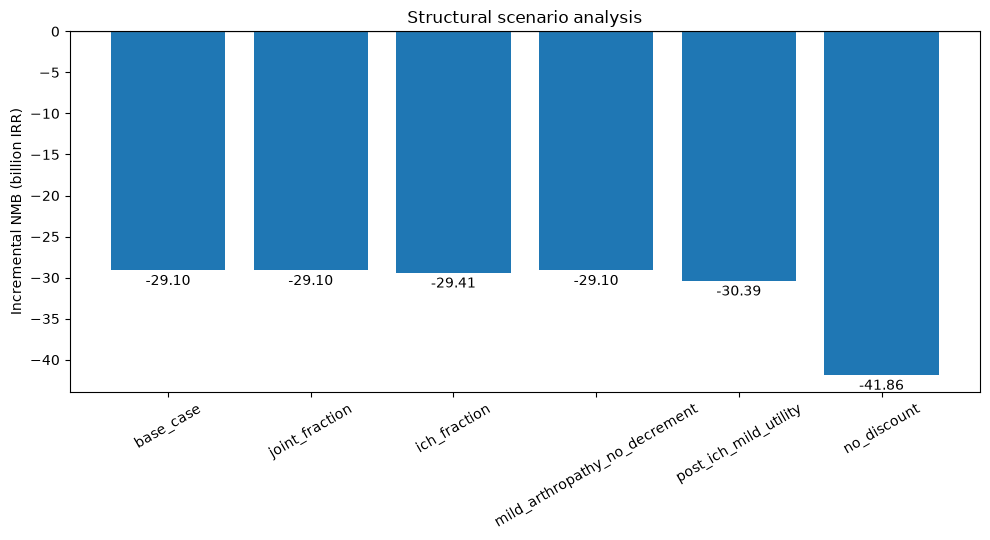

In [19]:
if scenario_table.height:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    plot_scenario_nmb_bars(scenario_table, ax=ax)
    fig.tight_layout()
    fig.savefig(FIGURES / "structural_scenarios.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / "structural_scenarios.pdf", bbox_inches="tight")
    plt.show()

## 7. Completed production PSA for CUA

The production analysis uses 2,500 second-order parameter draws with 5,000 patients per strategy
inside each draw. The 5,000-patient inner population controls first-order noise and is distinct
from the 50,000 patients used for the fixed-parameter deterministic base case. This target was
selected after measured runtime and convergence testing: it finishes within one hour and gives an
approximate worst-case 95% Monte Carlo margin of ±1.96 percentage points for CEAC probabilities.
Parameter draws, atomic checkpoints, code/data fingerprints and the completed manifest are stored
with the results.

In [20]:
from modular_models.state_transition.production import PSAConfig, PSAProductionPipeline

production_psa_dir = OUTPUT / "psa_production"
psa_config = PSAConfig(
    iterations=PSA_ITERATIONS,
    n_patients=PSA_PATIENTS_PER_ITERATION,
    output_dir=production_psa_dir,
    seed=MASTER_SEED,
    n_jobs=PSA_JOBS,
    batch_size=PSA_BATCH_SIZE,
    compute_backend=PSA_BACKEND,
)

if RUN_PRODUCTION_PSA:
    psa_frame = PSAProductionPipeline(context, psa_config).run()
    psa_source_label = "Probabilistic sensitivity analysis"
elif (production_psa_dir / "psa_results.parquet").exists():
    psa_frame = pl.read_parquet(production_psa_dir / "psa_results.parquet")
    psa_source_label = "Probabilistic sensitivity analysis"
else:
    convergence_psa_dir = ROOT / "outputs/state_transition/psa_convergence_500x5000"
    psa_frame = pl.read_parquet(convergence_psa_dir / "psa_results.parquet")
    psa_source_label = "500-iteration convergence run — NOT FINAL PSA"
    print(psa_source_label)

print(f"PSA source: {psa_source_label}; completed iterations: {psa_frame.height}")
psa_frame.head()

PSA source: Probabilistic sensitivity analysis; completed iterations: 2500


iteration,iteration_seed,scenario,n_patients_per_strategy,prophylaxis_cost_irr,on_demand_cost_irr,prophylaxis_qaly,on_demand_qaly,incremental_cost_irr,incremental_qaly,icer_irr_per_qaly,wtp_irr_per_qaly,incremental_nmb_irr,prophylaxis_cost_effective,prophylaxis_mean_cost_irr,prophylaxis_mean_qaly,prophylaxis_mean_life_years,prophylaxis_mean_factor_iu,prophylaxis_mean_joint_bleeds,prophylaxis_mean_non_major_non_joint_bleeds,prophylaxis_mean_non_ich_major_bleeds,prophylaxis_mean_ich,prophylaxis_mean_total_bleeds,prophylaxis_joint_bleed_rate_per_person_year,prophylaxis_non_major_non_joint_rate_per_person_year,prophylaxis_non_ich_major_rate_per_person_year,prophylaxis_ich_rate_per_person_year,prophylaxis_total_bleed_rate_per_person_year,prophylaxis_mean_pettersson_score,prophylaxis_survival_probability,prophylaxis_alive_at_end,prophylaxis_deaths_total,prophylaxis_deaths_background,prophylaxis_deaths_ich,prophylaxis_all_cause_mortality_probability,prophylaxis_post_ich_ever_count,prophylaxis_post_ich_ever_probability,on_demand_mean_cost_irr,on_demand_mean_qaly,on_demand_mean_life_years,on_demand_mean_factor_iu,on_demand_mean_joint_bleeds,on_demand_mean_non_major_non_joint_bleeds,on_demand_mean_non_ich_major_bleeds,on_demand_mean_ich,on_demand_mean_total_bleeds,on_demand_joint_bleed_rate_per_person_year,on_demand_non_major_non_joint_rate_per_person_year,on_demand_non_ich_major_rate_per_person_year,on_demand_ich_rate_per_person_year,on_demand_total_bleed_rate_per_person_year,on_demand_mean_pettersson_score,on_demand_survival_probability,on_demand_alive_at_end,on_demand_deaths_total,on_demand_deaths_background,on_demand_deaths_ich,on_demand_all_cause_mortality_probability,on_demand_post_ich_ever_count,on_demand_post_ich_ever_probability,mean_bleeds_avoided,relative_bleed_reduction,absolute_mortality_reduction,relative_mortality_reduction,deaths_avoided_per_1000,incremental_cost_per_bleed_avoided_irr
i64,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64
0,1683681671,"""base_case""",5000,4.1663e10,7.4633e9,8.097444,7.917153,3.4199e10,0.180291,1.8969e11,1.8000e10,-3.0954e10,false,4.1663e10,8.097444,10.980817,1.0270e6,11.4704,31.4806,0.1636,0.0024,43.117,1.044585,2.866872,0.014899,0.000219,3.926575,0.3658,0.9962,4981,19,19,0,0.0038,1,0.0002,7.4633e9,7.917153,10.946835,183961.940466,144.9868,13.9126,0.627,0.1966,159.723,13.244632,1.270924,0.057277,0.01796,14.590793,10.7544,0.9896,4948,52,19,33,0.0104,154,0.0308,116.606,0.730051,0.0066,0.634615,6.6,2.9329e8
1,3375720668,"""base_case""",5000,4.0815e10,8.4147e9,7.761395,7.648204,3.2401e10,0.113191,2.8625e11,1.8000e10,-3.0363e10,false,4.0815e10,7.761395,10.970079,1.0061e6,11.4952,18.965,0.1664,0.0038,30.6304,1.047868,1.728793,0.015169,0.000346,2.792177,0.2662,0.995,4975,25,24,1,0.005,0,0.0,8.4147e9,7.648204,10.966207,207378.884845,148.7974,5.99,0.8426,0.094,155.724,13.568721,0.546224,0.076836,0.008572,14.200352,10.4474,0.9942,4971,29,24,5,0.0058,75,0.015,125.0936,0.803303,0.0008,0.137931,0.8,2.5901e8
2,727838852,"""base_case""",5000,4.0361e10,6.3623e9,7.311389,7.099951,3.3999e10,0.211438,1.6080e11,1.8000e10,-3.0193e10,false,4.0361e10,7.311389,10.986222,994963.195725,11.0784,16.117,0.1944,0.0038,27.3936,1.00839,1.467019,0.017695,0.000346,2.49345,0.3166,0.9966,4983,17,17,0,0.0034,3,0.0006,6.3623e9,7.099951,10.9313,156804.601808,113.548,33.8164,1.0966,0.2206,148.6816,10.38742,3.093539,0.100317,0.020181,13.601457,8.4026,0.9866,4933,67,17,50,0.0134,261,0.0522,121.288,0.815757,0.01,0.746269,10.0,2.8032e8
3,2863750571,"""base_case""",5000,4.0532e10,6.6669e9,8.239359,7.942652,3.3865e10,0.296707,1.1414e11,1.8000e10,-2.8524e10,false,4.0532e10,8.239359,10.961157,999075.630154,11.4284,26.6038,0.1434,0.0062,38.1818,1.042627,2.427098,0.013083,0.000566,3.483373,0.3628,0.9938,4969,31,28,3,0.0062,4,0.000

In [21]:
draws_path = (
    production_psa_dir / "parameter_draws.parquet"
    if (production_psa_dir / "parameter_draws.parquet").exists()
    else ROOT
    / "outputs/state_transition/psa_convergence_500x5000/parameter_draws.parquet"
)
parameter_draws = pl.read_parquet(draws_path)
iteration_zero = parameter_draws.filter(pl.col("iteration") == 0).join(
    psa_frame.filter(pl.col("iteration") == 0),
    on=["iteration", "iteration_seed"],
    how="inner",
)
iteration_zero.select(
    "iteration",
    "iteration_seed",
    "abr_prophylaxis",
    "abr_on_demand",
    "ich_rate_prophylaxis",
    "ich_rate_on_demand",
    "factor_price_irr_per_iu",
    "utility_anchor",
    "incremental_cost_irr",
    "incremental_qaly",
    "prophylaxis_deaths_ich",
    "on_demand_deaths_ich",
    "prophylaxis_post_ich_ever_count",
    "on_demand_post_ich_ever_count",
)

iteration,iteration_seed,abr_prophylaxis,abr_on_demand,ich_rate_prophylaxis,ich_rate_on_demand,factor_price_irr_per_iu,utility_anchor,incremental_cost_irr,incremental_qaly,prophylaxis_deaths_ich,on_demand_deaths_ich,prophylaxis_post_ich_ever_count,on_demand_post_ich_ever_count
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0,1683681671,3.927835,14.634886,0.000194,0.018303,58000.0,0.956217,3.4199e10,0.180291,0,33,1,154


In [22]:
psa_statistics = psa_summary(psa_frame)
quadrants = cost_effectiveness_quadrants(psa_frame)
wtp_grid = np.linspace(0, 200_000_000_000, 101)
ceac = ceac_table(psa_frame, wtp_grid)
psa_statistics.write_csv(TABLES / "psa_summary.csv")
quadrants.write_csv(TABLES / "psa_quadrants.csv")
ceac.write_csv(TABLES / "psa_ceac.csv")

psa_statistics

metric,n,mean,sd,median,p2_5,p97_5
str,i64,f64,f64,f64,f64,f64
"""incremental_cost_irr""",2500,3.3385e10,1.1029e9,3.3456e10,3.1169e10,3.5411e10
"""incremental_qaly""",2500,0.233836,0.086509,0.217287,0.109923,0.444556
"""icer_irr_per_qaly""",2500,1.6271e11,6.1209e10,1.5351e11,7.4753e10,3.0636e11
"""incremental_nmb_irr""",2500,-2.9176e10,1.9703e9,-2.9364e10,-3.2569e10,-2.4955e10
"""mean_bleeds_avoided""",2500,117.418135,12.466244,117.67,93.62905,140.061755
"""absolute_mortality_reduction""",2500,0.014651,0.013016,0.0108,0.001,0.04941
"""relative_mortality_reduction""",2500,0.649081,0.197217,0.691267,0.172414,0.91223


In [23]:
quadrants

quadrant,count,proportion
str,i64,f64
"""north_east_more_cost_more_effe…",2500,1.0
"""south_east_dominant""",0,0.0
"""north_west_dominated""",0,0.0
"""south_west_less_cost_less_effe…",0,0.0


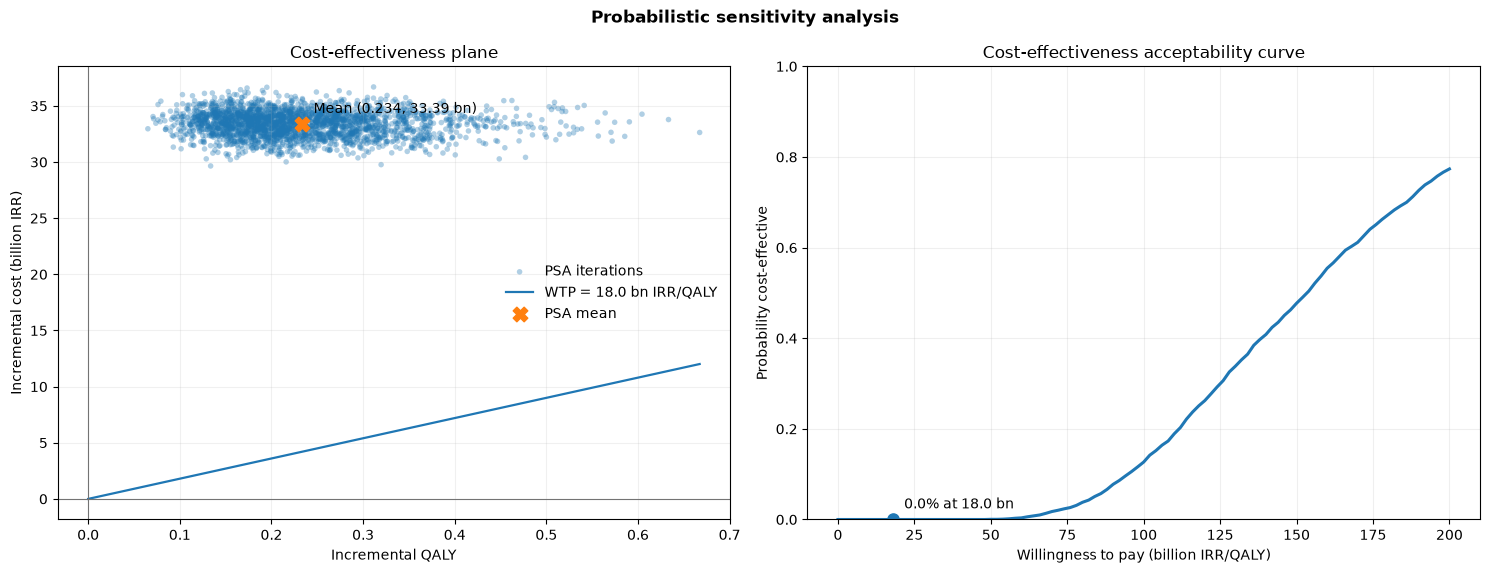

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
plot_psa_plane(psa_frame, WTP_IRR_PER_QALY, axes[0])
plot_ceac_frame(ceac, WTP_IRR_PER_QALY, axes[1])
fig.suptitle(psa_source_label, fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "psa_plane_and_ceac.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "psa_plane_and_ceac.pdf", bbox_inches="tight")
plt.show()

In [25]:
# Selected CEAC probabilities

selected_wtp_billion = [0, 18, 50, 100, 125, 150, 175, 200]
selected_wtp_values = [float(wtp) for wtp in selected_wtp_billion]
selected_ceac = selected_ceac_table(ceac, selected_wtp_values)
selected_ceac

wtp_irr_per_qaly,probability_cost_effective,wtp_billion_irr_per_qaly
f64,f64,f64
0.0,0.0,0.0
1.8000e10,0.0,18.0
5.0000e10,0.0004,50.0
1.0000e11,0.1268,100.0
1.5000e11,0.4772,150.0
2.0000e11,0.7736,200.0


In [26]:
# CEAC probabilities calculated exactly at selected WTP values

selected_wtp = np.array([0, 18e9, 50e9, 100e9, 125e9, 150e9, 175e9, 200e9], dtype=float)
selected_ceac_exact = exact_ceac_table(psa_frame, selected_wtp, WTP_IRR_PER_QALY)
selected_ceac_exact

wtp_billion_irr_per_qaly,probability_prophylaxis_cost_effective
f64,f64
0.0,0.0
18.0,0.0
50.0,0.0004
100.0,0.1268
125.0,0.3
150.0,0.4772
175.0,0.646
200.0,0.7736


## 8. PSA computational precision and CUDA audit

Three nested quantities are distinguished: 50,000 patients stabilize the deterministic base case;
5,000 patients control first-order patient noise inside each PSA draw; and 2,500 PSA draws control
second-order parameter-uncertainty precision. The inner-loop diagnostic reused identical parameter
draws and seeds at every candidate population size. CUDA 13.2 was validated against the CPU event
history and QALY results, but the CPU-JIT process pool was faster on the GTX 1660 Ti because this
model uses FP64 arithmetic and frequent weekly state updates.

In [27]:
inner_precision = pl.read_parquet(
    ROOT
    / "outputs/state_transition/psa_inner_precision_final/inner_loop_precision.parquet"
).with_columns(
    (100 * pl.col("relative_mean_difference_cost")).alias(
        "mean_cost_difference_percent"
    ),
    (100 * pl.col("relative_mean_difference_qaly")).alias(
        "mean_qaly_difference_percent"
    ),
    (100 * pl.col("noise_to_parameter_sd_qaly")).alias("qaly_noise_ratio_percent"),
)
inner_precision.write_csv(TABLES / "psa_inner_loop_precision.csv")
inner_precision.write_parquet(TABLES / "psa_inner_loop_precision.parquet")
inner_precision.select(
    "n_patients_per_strategy",
    "common_iterations",
    "mean_cost_difference_percent",
    "mean_qaly_difference_percent",
    "qaly_noise_ratio_percent",
    "cost_effectiveness_agreement",
    "means_within_threshold",
)

n_patients_per_strategy,common_iterations,mean_cost_difference_percent,mean_qaly_difference_percent,qaly_noise_ratio_percent,cost_effectiveness_agreement,means_within_threshold
i64,i64,f64,f64,f64,f64,bool
1000,40,0.000919,0.225267,28.838833,1.0,true
2500,40,0.009259,0.759902,16.856805,1.0,true
5000,40,0.001039,0.613266,8.136861,1.0,true
10000,40,0.0,0.0,0.0,1.0,true


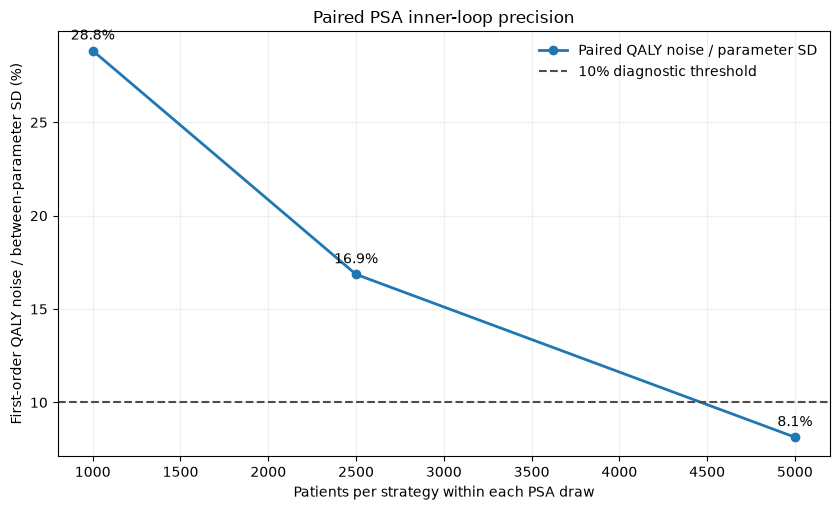

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
precision_plot = inner_precision.filter(pl.col("n_patients_per_strategy") < 10_000)
plot_inner_loop_precision(precision_plot, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES / "psa_inner_loop_precision.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "psa_inner_loop_precision.pdf", bbox_inches="tight")
plt.show()

In [29]:
iteration_checkpoints = [50, 100, 200, 300, 400, 500, 1_000, 2_500, 5_000, 10_000]
iteration_convergence = psa_iteration_convergence(psa_frame, iteration_checkpoints)
iteration_convergence.write_csv(TABLES / "psa_iteration_convergence.csv")
iteration_convergence.write_parquet(TABLES / "psa_iteration_convergence.parquet")

precision_summary = psa_precision_summary(psa_frame)
precision_summary.write_csv(TABLES / "psa_precision_summary.csv")
precision_summary

completed_iterations,relative_mcse_mean_incremental_qaly,iterations_estimated_for_1pct_relative_mcse_qaly,worst_case_95pct_ceac_margin_at_2500,worst_case_95pct_ceac_margin_at_10000,rule_of_three_upper_probability_if_zero_events
i64,f64,i64,f64,f64,f64
2500,0.007399,1369,0.0196,0.0098,0.0012


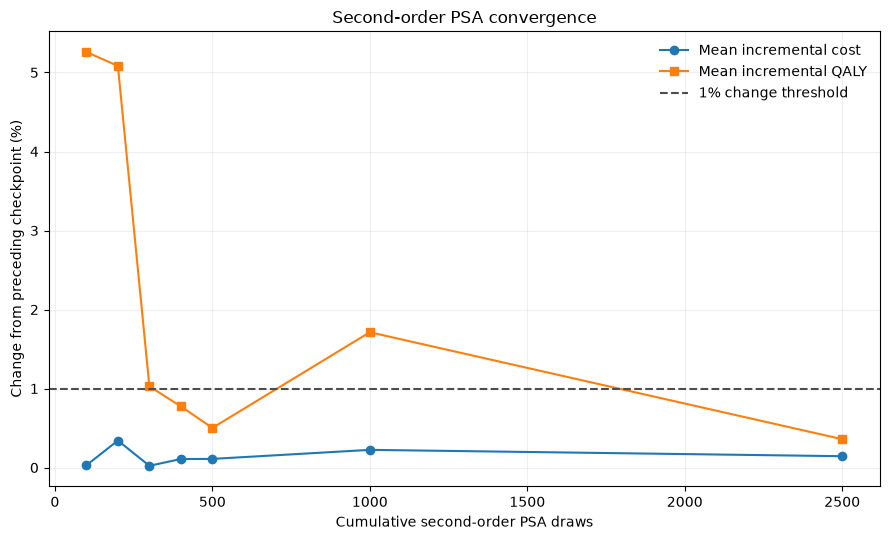

iterations,mean_incremental_cost_irr,mean_incremental_qaly,mean_incremental_nmb_irr,p2_5_incremental_cost_irr,p97_5_incremental_cost_irr,p2_5_incremental_qaly,p97_5_incremental_qaly,probability_cost_effective,probability_mcse,relative_change_mean_cost,relative_change_mean_qaly,absolute_change_probability,converged_from_previous_checkpoint
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
50,3.3470e10,0.208099,-2.9724e10,3.1494e10,3.5311e10,0.104571,0.362401,0.0,0.0,null,null,null,false
100,3.3480e10,0.219043,-2.9537e10,3.1439e10,3.5342e10,0.105564,0.401194,0.0,0.0,0.000291,0.052589,0.0,false
200,3.3365e10,0.230177,-2.9222e10,3.1254e10,3.5445e10,0.11175,0.408637,0.0,0.0,0.003422,0.05083,0.0,false
300,3.3358e10,0.22781,-2.9257e10,3.1281e10,3.5511e10,0.112466,0.415075,0.0,0.0,0.000225,0.010281,0.0,false
400,3.3322e10,0.229575,-2.9189e10,3.1254e10,3.5488e10,0.11175,0.421733,0.0,0.0,0.001085,0.007746,0.0,true
500,3.3358e10,0.230728,-2.9205e10,3.1260e10,3.5451e10,0.112466,0.419635,0.0,0.0,0.001098,0.005021,0.0,true
1000,3.3433e10,0.23468,-2.9209e10,3.1316e10,3.5433e10,0.108222,0.439829,0.0,0.0,0.002244,0.017128,0.0,false
2500,3.3385e10,0.233836,-2.9176e10,3.1169e10,3.5411e10,0.109923,0.444556,0.0,0.0,0.001441,0.003595,0.0,true


In [30]:
convergence_plot = iteration_convergence.filter(
    pl.col("relative_change_mean_cost").is_not_null()
)
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_psa_convergence(
    convergence_plot,
    title=f"Second-order PSA convergence",
    ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES / "psa_iteration_convergence.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "psa_iteration_convergence.pdf", bbox_inches="tight")
plt.show()
iteration_convergence

In [31]:
# Expected Value of Perfect Information (EVPI)
# calculated directly from completed PSA draws

assert psa_frame.height > 0
evpi_wtp_billion: list[float] = [0, 18, 50, 100, 125, 150, 175, 200, 250, 300]
evpi_table_df = evpi_table(psa_frame, evpi_wtp_billion)
evpi_table_df.write_csv(TABLES / "evpi_by_wtp.csv")
evpi_table_df

wtp_billion_irr_per_qaly,mean_inmb_billion_irr,probability_prophylaxis_cost_effective,evpi_billion_irr_per_patient,evpi_irr_per_patient
f64,f64,f64,f64,f64
0.0,-33.385011,0.0,0.0,0.0
18.0,-29.175961,0.0,0.0,0.0
50.0,-21.693206,0.0004,0.000293,292953.111693
100.0,-10.001402,0.1268,0.858494,8.5849e8
125.0,-4.1555,0.3,2.764316,2.7643e9
150.0,1.690403,0.4772,4.188272,4.1883e9
175.0,7.536305,0.646,2.431483,2.4315e9
200.0,13.382207,0.7736,1.377618,1.3776e9
250.0,25.074012,0.9128,0.417132,4.1713e8


In [32]:
# Maximum EVPI over a fine WTP grid

evpi_grid_wtp = np.linspace(0, 300e9, 601)
max_evpi_irr, max_evpi_wtp_billion = evpi_max(psa_frame, evpi_grid_wtp)

print(
    "Maximum EVPI:",
    f"{max_evpi_irr / 1e9:.4f}",
    "billion IRR/patient",
)
print(
    "WTP at maximum EVPI:",
    f"{max_evpi_wtp_billion:.1f}",
    "billion IRR/QALY",
)

Maximum EVPI: 4.8498 billion IRR/patient
WTP at maximum EVPI: 143.0 billion IRR/QALY


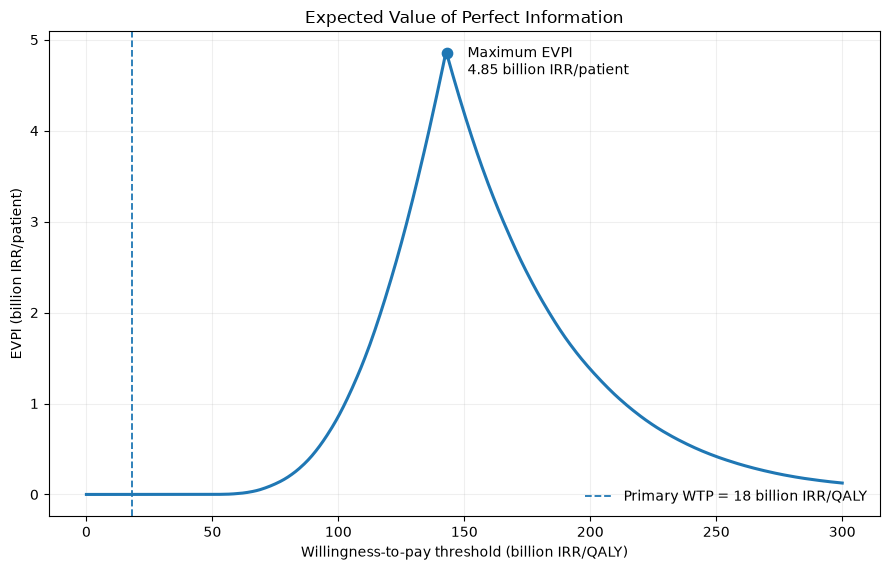

In [33]:
# EVPI across WTP thresholds

from modular_models.state_transition.reporting import evpi_grid as _evpi_grid

evpi_grid_wtp, evpi_grid_values = _evpi_grid(psa_frame, evpi_grid_wtp)

fig, ax = plt.subplots(figsize=(9, 5.8))
plot_evpi(evpi_grid_wtp, evpi_grid_values, WTP_IRR_PER_QALY, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES / "evpi_by_wtp.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "evpi_by_wtp.pdf", bbox_inches="tight")
plt.show()

In [34]:
# Deterministic FVIII price threshold at the primary WTP

assert base is not None
BASE_FACTOR_PRICE = 58_000.0
PRIMARY_WTP = float(WTP_IRR_PER_QALY)

price_breakdown = break_even_factor_price(base, PRIMARY_WTP, BASE_FACTOR_PRICE)
break_even_factor_price_irr = price_breakdown["break_even_factor_price_irr_per_iu"]
required_price_reduction = price_breakdown["required_price_reduction_fraction"]

print(f"Base FVIII price: {BASE_FACTOR_PRICE:,.0f} IRR/IU")
print(
    f"Break-even FVIII price at WTP "
    f"{PRIMARY_WTP / 1e9:.0f} billion IRR/QALY: "
    f"{break_even_factor_price_irr:,.0f} IRR/IU"
)
print(f"Required reduction from base price: {required_price_reduction * 100:.2f}%")

Base FVIII price: 58,000 IRR/IU
Break-even FVIII price at WTP 18 billion IRR/QALY: 7,513 IRR/IU
Required reduction from base price: 87.05%


In [35]:
# Deterministic policy scenarios for FVIII price reductions

price_reduction_percent = np.array(
    [0, 20, 40, 50, 60, 70, 80, 85, 87, 87.5, 90, 95], dtype=float
)
assert base is not None

factor_price_policy = factor_price_policy_table(
    base, BASE_FACTOR_PRICE, PRIMARY_WTP, price_reduction_percent
)
factor_price_policy.write_csv(TABLES / "factor_viii_price_policy.csv")
factor_price_policy

price_reduction_percent,factor_price_irr_per_iu,incremental_cost_billion_irr,incremental_qaly,icer_billion_irr_per_qaly,inmb_billion_irr_per_patient,cost_effective_at_primary_wtp
f64,f64,f64,f64,f64,f64,f64
0.0,58000.0,33.428021,0.240558,138.960332,-29.097977,0.0
20.0,46400.0,26.742417,0.240558,111.168266,-22.412373,0.0
40.0,34800.0,20.056813,0.240558,83.376199,-15.726769,0.0
50.0,29000.0,16.714011,0.240558,69.480166,-12.383967,0.0
60.0,23200.0,13.371209,0.240558,55.584133,-9.041164,0.0
…,…,…,…,…,…,…
85.0,8700.0,5.014203,0.240558,20.84405,-0.684159,0.0
87.0,7540.0,4.345643,0.240558,18.064843,-0.015599,0.0
87.5,7250.0,4.178503,0.240558,17.370042,0.151542,1.0


In [36]:
# Probabilistic FVIII price policy analysis using completed PSA draws

BASE_FACTOR_PRICE = 58_000.0
PRIMARY_WTP = float(WTP_IRR_PER_QALY)
price_grid = np.linspace(2_000, 58_000, 113)
factor_price_psa = factor_price_psa_table(
    psa_frame, BASE_FACTOR_PRICE, PRIMARY_WTP, price_grid
)
factor_price_psa.write_csv(TABLES / "factor_viii_price_policy_psa.csv")
factor_price_psa

factor_price_irr_per_iu,price_reduction_percent,mean_inmb_billion_irr,probability_cost_effective
f64,f64,f64,f64
2000.0,96.551724,3.057842,1.0
2500.0,95.689655,2.770041,0.996
3000.0,94.827586,2.482239,0.9892
3500.0,93.965517,2.194437,0.9712
4000.0,93.103448,1.906635,0.9296
…,…,…,…
56000.0,3.448276,-28.024754,0.0
56500.0,2.586207,-28.312556,0.0
57000.0,1.724138,-28.600358,0.0


In [37]:
# FVIII prices associated with selected probabilities of cost-effectiveness

targets = [0.50, 0.75, 0.90, 0.95]
factor_price_probability_thresholds = factor_price_probability_thresholds(
    factor_price_psa, targets
)
factor_price_probability_thresholds

target_probability,maximum_price_irr_per_iu,required_price_reduction_percent
f64,f64,f64
0.5,6500.0,88.793103
0.75,5000.0,91.37931
0.9,4000.0,93.103448
0.95,3500.0,93.965517


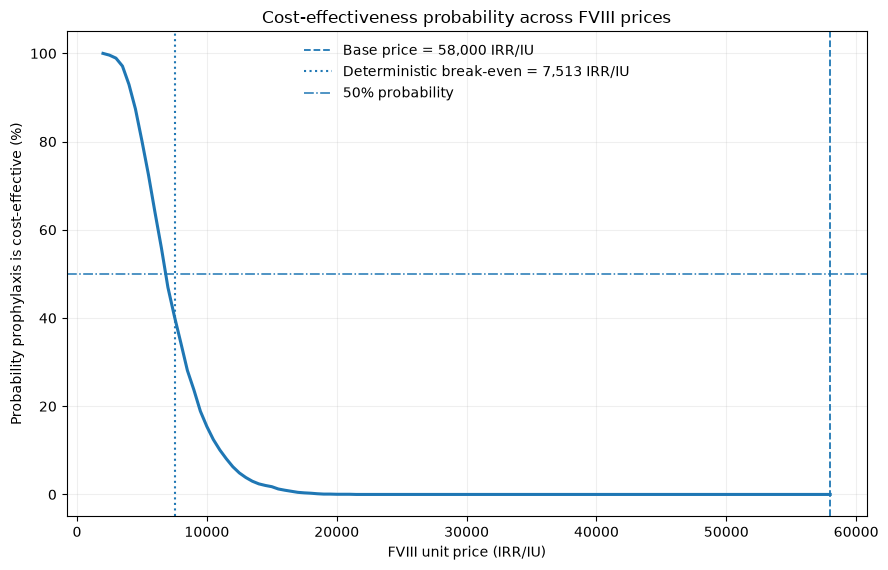

In [38]:
# Probability of cost-effectiveness versus FVIII unit price

fig, ax = plt.subplots(figsize=(9, 5.8))
plot_factor_price_policy(
    factor_price_psa, BASE_FACTOR_PRICE, break_even_factor_price_irr, ax=ax
)
fig.tight_layout()
fig.savefig(FIGURES / "factor_viii_price_policy.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "factor_viii_price_policy.pdf", bbox_inches="tight")
plt.show()

## 9. Checkpointed production OWSA

Each low/high endpoint is an independent atomic checkpoint. Inactive structural parameters and
technical convergence controls are excluded. Because AJBR is a subset of ABR, the infeasible
high on-demand AJBR endpoint is paired with the documented high ABR. The audit labels this as a
linked endpoint and stores both overrides; it is not described as pure OWSA.

In [39]:
from modular_models.state_transition.production import (
    OWSAConfig,
    OWSAProductionPipeline,
)

production_owsa_dir = OUTPUT / "owsa_production"
owsa_config = OWSAConfig(
    n_patients=PRODUCTION_PATIENTS,
    output_dir=production_owsa_dir,
    seed=MASTER_SEED,
    n_jobs=OWSA_JOBS,
)
if RUN_PRODUCTION_OWSA:
    owsa_frame = OWSAProductionPipeline(context, owsa_config).run()
    owsa_source_label = "FINAL production OWSA"
elif (production_owsa_dir / "owsa_results.parquet").exists():
    owsa_frame = pl.read_parquet(production_owsa_dir / "owsa_results.parquet")
    owsa_source_label = "Existing production OWSA"
else:
    owsa_frame = pl.read_parquet(
        ROOT / "outputs/state_transition/owsa_pilot_linked/owsa_results.parquet"
    )
    owsa_source_label = "1,000-patient linked-endpoint pilot — NOT FINAL OWSA"
    print(owsa_source_label)

owsa_audit = owsa_frame.filter(
    (pl.col("analysis_type") == "linked_endpoint") | (pl.col("status") != "complete")
).select(
    "parameter_id",
    "endpoint",
    "endpoint_value",
    "analysis_type",
    "linked_parameter_id",
    "linked_endpoint_value",
    "overrides_json",
    "status",
    "error",
)
print(
    f"Complete endpoints: {owsa_frame.filter(pl.col('status') == 'complete').height}/{owsa_frame.height}"
)
owsa_audit

Complete endpoints: 60/60


parameter_id,endpoint,endpoint_value,analysis_type,linked_parameter_id,linked_endpoint_value,overrides_json,status,error
str,str,f64,str,str,f64,str,str,null
"""ajbr_on_demand""","""high""",14.2,"""linked_endpoint""","""abr_on_demand""",15.6,"""{""abr_on_demand"": 15.6, ""ajbr_…","""complete""",null


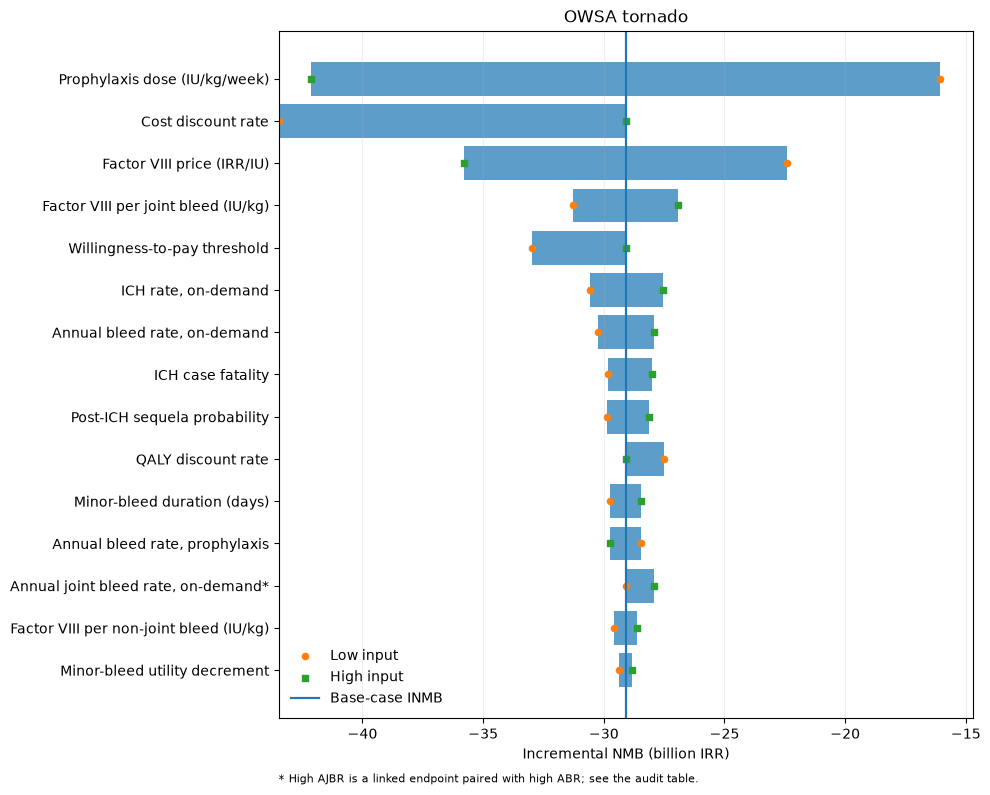

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))
assert base is not None
plot_owsa_frame(owsa_frame, base.incremental_nmb_irr, limit=15, ax=ax)
ax.set_title(f"OWSA tornado")
fig.tight_layout()
fig.savefig(FIGURES / "owsa_tornado.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "owsa_tornado.pdf", bbox_inches="tight")
plt.show()

In [41]:
# OWSA numerical ranking

assert base is not None
assert owsa_frame.height > 0
BASE_INMB = float(base.incremental_nmb_irr)
owsa_thesis_summary = owsa_parameter_ranking(owsa_frame, BASE_INMB, top_n=15)
owsa_thesis_summary.write_csv(TABLES / "thesis_owsa_parameter_ranking.csv")

print(f"Base-case INMB: {BASE_INMB / 1e9:.3f} billion IRR")
print(
    "Parameters with at least one endpoint making prophylaxis cost-effective:",
    owsa_thesis_summary.filter(pl.col("any_endpoint_cost_effective")).height,
)
owsa_thesis_summary.head(15)

Base-case INMB: -29.098 billion IRR
Parameters with at least one endpoint making prophylaxis cost-effective: 0


sensitivity_rank,parameter_id,parameter_description,unit,base_value,low_value,high_value,INMB_low_billion_IRR,INMB_high_billion_IRR,INMB_range_billion_IRR,ICER_low_billion_IRR_per_QALY,ICER_high_billion_IRR_per_QALY,any_endpoint_cost_effective,high_endpoint_type,linked_parameter_id,linked_endpoint_value
u32,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,bool,str,str,f64
1,"""prophylaxis_iu_per_kg_week""","""25 IU/kg three times weekly""","""IU/kg/week""",75.0,50.0,100.0,-16.0725,-42.123455,26.050955,84.813404,193.107261,false,"""one_way""",null,null
2,"""cost_discount_rate""","""Annual discount rate for costs""","""proportion/year""",0.058,0.0,0.058,-43.469501,-29.097977,14.371524,198.702776,138.960332,false,"""one_way""",null,null
3,"""factor_price_irr_per_iu""","""Official unit price of plasma-…","""IRR/IU""",58000.0,46400.0,69600.0,-22.412373,-35.783582,13.371209,111.168266,166.752399,false,"""one_way""",null,null
4,"""joint_bleed_iu_per_kg""","""FVIII consumption per joint bl…","""IU/kg/event""",50.0,25.0,75.0,-31.28155,-26.914405,4.367145,148.037445,129.883219,false,"""one_way""",null,null
5,"""wtp_irr_per_qaly""","""Primary orphan-disease willing…","""IRR/QALY""",1.8000e10,1.8000e9,1.8000e10,-32.995017,-29.097977,3.89704,138.960332,138.960332,false,"""one_way""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,"""minor_bleed_duration_days""","""Acute utility duration for min…","""day/event""",2.0,1.0,3.0,-29.760184,-28.466241,1.293942,164.048791,121.267843,false,"""one_way""",null,null
12,"""abr_prophylaxis""","""Annual bleeding rate under pro…","""event/patient-year""",3.05,2.1,4.0,-28.474206,-29.722871,1.248665,132.949702,145.335108,false,"""one_way""",null,null
13,"""ajbr_on_demand""","""Direct annualized joint bleedi…","""event/patient-year""",9.85,5.5,14.2,-29.095881,-27.912062,1.183819,138.939325,127.609323,false,"""linked_endpoint""","""abr_on_demand""",15.6


## 10. Runtime and accelerator completion audit

The table compares measured CPU and CUDA benchmarks with the completed production PSA. CUDA is
retained as an optional, tested backend, while the faster measured backend is used for the final
CUA uncertainty analysis. Runtime values are empirical model-run metadata, not health outcomes.

In [42]:
import json

from modular_models.state_transition.rewards import cuda_available, cuda_runtime_info
import math

production_manifest = json.loads(
    (production_psa_dir / "manifest.json").read_text(encoding="utf-8")
)
cuda_manifest_path = OUTPUT / "benchmark_cuda_8workers_5000" / "manifest.json"

if not cuda_manifest_path.exists():
    cuda_candidates = sorted(OUTPUT.glob("benchmark_cuda*/manifest.json"))
    if cuda_candidates:
        cuda_manifest_path = cuda_candidates[0]

if cuda_manifest_path.exists():
    cuda_benchmark_manifest = json.loads(cuda_manifest_path.read_text(encoding="utf-8"))
else:
    cuda_benchmark_manifest = {
        "schema_version": 2,
        "analysis": "benchmark",
        "status": "unavailable",
        "config": {
            "n_patients": 5000,
            "n_jobs": 0,
            "compute_backend": "cuda",
        },
        "completed": 0,
        "elapsed_seconds_this_session": None,
        "parallel_backend": None,
    }
    print("CUDA benchmark manifest not found; CUDA audit marked unavailable.")
cpu_manifest_path = OUTPUT / "benchmark_cpu_final_12workers_5000" / "manifest.json"

if not cpu_manifest_path.exists():
    cpu_candidates = sorted(OUTPUT.glob("benchmark_cpu*/manifest.json"))
    if cpu_candidates:
        cpu_manifest_path = cpu_candidates[0]

if cpu_manifest_path.exists():
    cpu_benchmark_manifest = json.loads(cpu_manifest_path.read_text(encoding="utf-8"))
else:
    cpu_benchmark_manifest = {
        "schema_version": 2,
        "analysis": "benchmark",
        "status": "unavailable",
        "config": {
            "n_patients": 5000,
            "n_jobs": 12,
            "compute_backend": "cpu",
        },
        "completed": 0,
        "elapsed_seconds_this_session": None,
        "parallel_backend": None,
    }
    print("CPU benchmark manifest not found; CPU audit marked unavailable.")


def _ensure_runtime_manifest_iterations(manifest, default_iterations=1):
    normalized = dict(manifest)
    config = dict(normalized.get("config") or {})

    iterations = (
        config.get("iterations")
        or normalized.get("iterations")
        or normalized.get("completed")
        or default_iterations
    )

    config["iterations"] = int(iterations)
    normalized["config"] = config
    return normalized


production_manifest = _ensure_runtime_manifest_iterations(production_manifest)
cpu_benchmark_manifest = _ensure_runtime_manifest_iterations(cpu_benchmark_manifest)
cuda_benchmark_manifest = _ensure_runtime_manifest_iterations(cuda_benchmark_manifest)


def _ensure_runtime_manifest_fields(manifest, default_jobs):
    normalized = dict(manifest)
    config = dict(normalized.get("config") or {})

    configured_jobs = config.get("n_jobs", default_jobs)
    effective_jobs = normalized.get("effective_jobs")

    if effective_jobs is None:
        effective_jobs = (
            configured_jobs if configured_jobs and configured_jobs > 0 else 1
        )

    normalized["effective_jobs"] = int(effective_jobs)
    normalized.setdefault(
        "parallel_backend",
        "process" if effective_jobs > 1 else "serial",
    )
    normalized.setdefault("elapsed_seconds_this_session", None)
    normalized["config"] = config
    return normalized


production_manifest = _ensure_runtime_manifest_fields(production_manifest, 12)
cpu_benchmark_manifest = _ensure_runtime_manifest_fields(cpu_benchmark_manifest, 12)
cuda_benchmark_manifest = _ensure_runtime_manifest_fields(cuda_benchmark_manifest, 1)

for manifest in (
    production_manifest,
    cpu_benchmark_manifest,
    cuda_benchmark_manifest,
):
    elapsed = manifest.get("elapsed_seconds_this_session")
    if elapsed is None:
        manifest["elapsed_seconds_this_session"] = math.nan

runtime_table = runtime_audit_table(
    production_manifest,
    cpu_benchmark_manifest,
    cuda_benchmark_manifest,
)
runtime_table.write_csv(TABLES / "runtime_feasibility.csv")
runtime_table.write_parquet(TABLES / "runtime_feasibility.parquet")

cuda_audit = pl.DataFrame(
    [
        {
            "cuda_available": cuda_available(),
            **(cuda_runtime_info() if cuda_available() else {}),
            "selected_for_final_psa": False,
            "selection_reason": "Validated but slower than 12-core CPU-JIT for FP64 rewards",
        }
    ]
)
cuda_audit.write_csv(TABLES / "cuda_runtime_audit.csv")
runtime_table

CUDA benchmark manifest not found; CUDA audit marked unavailable.
CPU benchmark manifest not found; CPU audit marked unavailable.


run,iterations,patients_per_strategy,worker_processes,backend,elapsed_minutes,status
str,i64,i64,i64,str,f64,str
"""CPU benchmark""",1,5000,12,"""CPU JIT process pool""",NaN,"""unavailable"""
"""CUDA benchmark""",1,5000,1,"""CUDA FP64 reward kernel""",NaN,"""unavailable"""
"""Final PSA""",2500,5000,12,"""CPU JIT process pool""",36.316493,"""complete"""


## 11. Deterministic first-order Monte Carlo convergence

The fixed-parameter deterministic cohort size is accepted only when relative changes in both
incremental cost and incremental QALY are below the pre-specified 1% threshold. This criterion is
different from selecting patients within PSA and from selecting the number of PSA draws.

n_patients,incremental_cost_irr,incremental_qaly,relative_change_cost,relative_change_qaly
i64,f64,f64,f64,f64
10000,3.3420e10,0.244874,null,null
25000,3.3427e10,0.241448,0.000197,0.013988
50000,3.3428e10,0.240558,0.000036,0.003688
100000,3.3429e10,0.23849,0.000024,0.008595


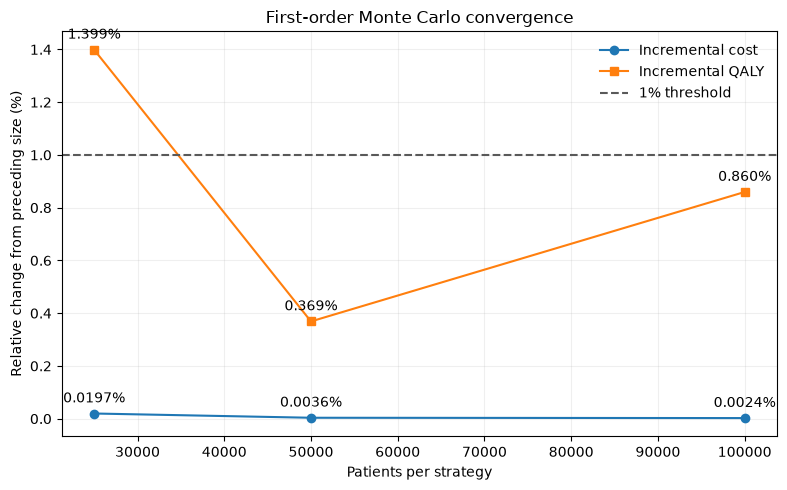

In [43]:
convergence_path = OUTPUT / "convergence.json"

if convergence_path.exists():
    convergence_records = json.loads(convergence_path.read_text(encoding="utf-8"))
else:
    # convergence_sizes = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000]
    convergence_sizes = [10_000, 25_000, 50_000, 100_000]
    convergence_records = []
    previous_cost = None
    previous_qaly = None

    for n_patients in convergence_sizes:
        result = runner.compare(
            n_patients=n_patients,
            seed=MASTER_SEED,
            retain_patient_level=False,
        )

        incremental_cost = float(result.incremental_cost_irr)
        incremental_qaly = float(result.incremental_qaly)

        convergence_records.append(
            {
                "n_patients": n_patients,
                "incremental_cost_irr": incremental_cost,
                "incremental_qaly": incremental_qaly,
                "relative_change_cost": (
                    None
                    if previous_cost is None
                    else abs(incremental_cost - previous_cost) / abs(previous_cost)
                ),
                "relative_change_qaly": (
                    None
                    if previous_qaly is None
                    else abs(incremental_qaly - previous_qaly) / abs(previous_qaly)
                ),
            }
        )

        previous_cost = incremental_cost
        previous_qaly = incremental_qaly

    convergence_path.write_text(
        json.dumps(convergence_records, indent=2),
        encoding="utf-8",
    )
convergence_table = monte_carlo_convergence_table(convergence_records)
convergence_table.write_csv(TABLES / "monte_carlo_convergence.csv")
convergence_table.write_parquet(TABLES / "monte_carlo_convergence.parquet")

fig, ax = plt.subplots(figsize=(8, 5))
plot_monte_carlo_convergence(convergence_table, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES / "monte_carlo_convergence.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "monte_carlo_convergence.pdf", bbox_inches="tight")
display(convergence_table)
display(fig)
plt.close(fig)

## 12. Reporting checklist

The PSA values in this Notebook come from the completed 2,500-draw production manifest with 5,000
patients per strategy per draw. Before transferring values into the report, retain the model/data
fingerprints and disclose the approximate worst-case ±1.96 percentage-point CEAC Monte Carlo
margin. The linked high AJBR/high ABR result must be described as a linked sensitivity endpoint,
not pure one-way analysis. The 1,000-patient OWSA remains explicitly labeled as a pilot unless a
50,000-patient production OWSA is completed.

The deterministic and probabilistic tables contain the required CUA outcomes: costs, QALYs,
life-years, factor consumption, type-specific bleeds, bleeds avoided, relative bleed reduction,
survival, cause-specific mortality, post-ICH entry, ICER, INMB, uncertainty intervals, CE plane,
quadrants and CEAC.

In [44]:
# EET - monthly drug cost for Poverty Reduction scoring

assert base is not None

FVIII_PRICE_IRR_PER_IU = 58_000.0
HORIZON_MONTHS = 11 * 12  # age 1 to before age 12 = 132 months

# Total undiscounted FVIII use per patient from the simulated base case
proph_factor_iu = float(base.prophylaxis.summary["mean_factor_iu"])

monthly_fviii_iu = proph_factor_iu / HORIZON_MONTHS

monthly_drug_cost_irr = monthly_fviii_iu * FVIII_PRICE_IRR_PER_IU

print(f"Mean cumulative FVIII use, prophylaxis: " f"{proph_factor_iu:,.2f} IU/patient")
print(f"Mean monthly FVIII use: " f"{monthly_fviii_iu:,.2f} IU/patient-month")
print(f"Mean monthly drug cost: " f"{monthly_drug_cost_irr:,.0f} IRR/patient-month")

Mean cumulative FVIII use, prophylaxis: 1,002,612.26 IU/patient
Mean monthly FVIII use: 7,595.55 IU/patient-month
Mean monthly drug cost: 440,541,749 IRR/patient-month
